<a href="https://colab.research.google.com/github/esigelecParfait/Projet-Spark/blob/main/partie2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("CyclistesLogs").getOrCreate()

df = spark.read.csv(r"/content/sample_data/Cycliste/*.csv",header=True)

In [86]:
from pyspark.sql.functions import col
df.filter(col("id")==2).show(5)

+---+-------------------+--------+-----+-------+--------------------+------------------+
| id|          timestamp|sur_velo| velo|vitesse|            position|destination_finale|
+---+-------------------+--------+-----+-------+--------------------+------------------+
|  2|2018-01-01 00:01:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
|  2|2018-01-01 00:02:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
|  2|2018-01-01 00:03:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
|  2|2018-01-01 00:04:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
|  2|2018-01-01 00:05:00|   False|False|   0.02|(lon:41.90 lat:40...|             False|
+---+-------------------+--------+-----+-------+--------------------+------------------+
only showing top 5 rows


In [51]:
df.count()

4868396

In [52]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- sur_velo: string (nullable = true)
 |-- velo: string (nullable = true)
 |-- vitesse: string (nullable = true)
 |-- position: string (nullable = true)
 |-- destination_finale: string (nullable = true)



In [88]:
df = df.dropDuplicates(["id", "timestamp"])

In [89]:
df.count()

4868396

In [90]:
from pyspark.sql.functions import col


df.filter(col("id")==246).show(10)


+---+-------------------+--------+-----+-------+--------------------+------------------+
| id|          timestamp|sur_velo| velo|vitesse|            position|destination_finale|
+---+-------------------+--------+-----+-------+--------------------+------------------+
|246|2018-01-01 00:01:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:02:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:03:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:04:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:05:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:06:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:07:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:08:00|   False|False|   0.02|(lon:22.62 lat:9.63)|             False|
|246|2018-01-01 00:09

In [95]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, lag

window = Window.partitionBy("id").orderBy("timestamp")

In [94]:
df = df.withColumn(
    "prev_sur_velo",
    lag("sur_velo").over(window)
)

In [98]:
from pyspark.sql.functions import when

df = df.withColumn(
    "start_trip",
    when(
        (col("sur_velo") == True) & (col("prev_sur_velo") == False),
        1
    ).otherwise(0)
)

In [99]:
from pyspark.sql.functions import sum as spark_sum

df = df.withColumn(
    "trip_id",
    spark_sum("start_trip").over(window)
)

In [100]:
from pyspark.sql.functions import to_timestamp

df = df.withColumn(
    "timestamp",
    to_timestamp("timestamp")
)

In [101]:
from pyspark.sql.functions import min, max,col

trajets = df.filter(col("sur_velo") == True) \
    .groupBy("id", "trip_id") \
    .agg(
        min("timestamp").alias("start_time"),
        max("timestamp").alias("end_time")
    )
trajets.filter(col("id") == 246).show()

+---+-------+-------------------+-------------------+
| id|trip_id|         start_time|           end_time|
+---+-------+-------------------+-------------------+
|246|      1|2018-01-01 04:17:00|2018-01-01 14:27:00|
|246|      2|2018-01-01 16:18:00|2018-01-02 06:12:00|
|246|      3|2018-01-02 07:17:00|2018-01-02 22:17:00|
|246|      4|2018-01-02 22:44:00|2018-01-03 15:33:00|
|246|      5|2018-01-03 17:58:00|2018-01-04 11:51:00|
|246|      6|2018-01-04 16:18:00|2018-01-05 09:09:00|
|246|      7|2018-01-05 10:17:00|2018-01-14 11:16:00|
+---+-------+-------------------+-------------------+



id                     object
trip_id                 int64
start_time     datetime64[ns]
end_time       datetime64[ns]
duration      timedelta64[ns]
dtype: object
     id  trip_id          start_time            end_time  duration
1635  2        1 2018-01-01 06:27:00 2018-01-01 16:45:00   37080.0
1636  2        2 2018-01-01 17:33:00 2018-01-02 14:41:00   76080.0
1637  2        3 2018-01-02 18:06:00 2018-01-03 05:19:00   40380.0
1638  2        4 2018-01-10 06:15:00 2018-01-11 20:51:00  138960.0


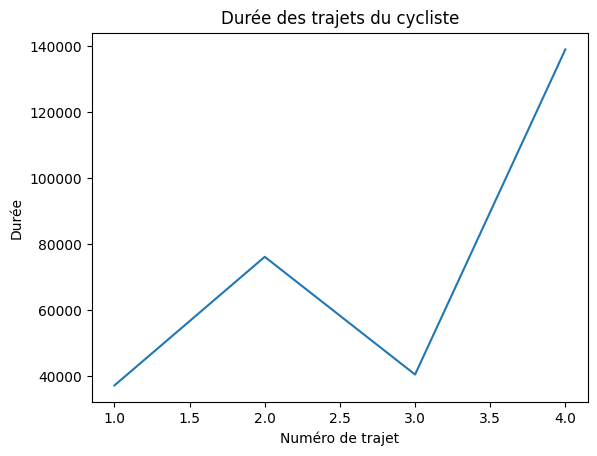

In [102]:
trajets = trajets.withColumn(
    "duration",
    col("end_time") - col("start_time")
)
graphique=trajets.toPandas()
graphique['duration']=graphique['duration'].dt.total_seconds()

graphique = graphique[graphique['id'] == "2"]


import matplotlib.pyplot as plt

plt.figure()

plt.plot(graphique["trip_id"], graphique["duration"])

plt.xlabel("Numéro de trajet")
plt.ylabel("Durée")
plt.title("Durée des trajets du cycliste")

plt.show()



In [16]:
from pyspark.sql.functions import unix_timestamp

df = df.withColumn(
    "timestamp",
    unix_timestamp("timestamp")
)

In [17]:
cycliste_id = 246

cycliste_df = trajets.filter(trajets.id == cycliste_id)

,id,trip_id,start_time,end_time,duration
0,246,1,1514780220,1514816820,0 days 10:10:00
1,246,2,1514823480,1514873520,0 days 13:54:00
2,246,3,1514877420,1514931420,0 days 15:00:00
3,246,4,1514933040,1514993580,0 days 16:49:00
4,246,5,1515002280,1515066660,0 days 17:53:00
5,246,6,1515082680,1515143340,0 days 16:51:00
6,246,7,1515147420,1515928560,9 days 00:59:00


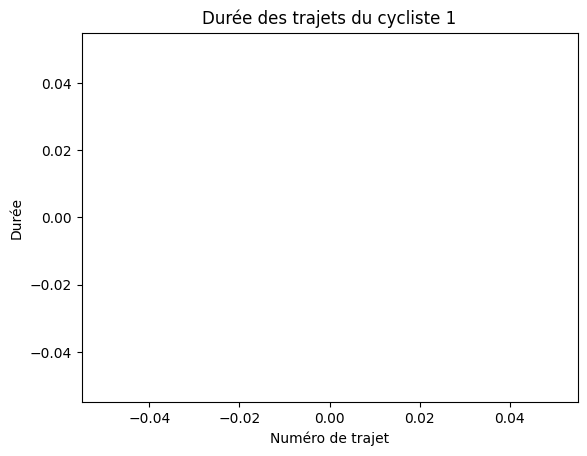

+---+-------+----------+--------+--------+
| id|trip_id|start_time|end_time|duration|
+---+-------+----------+--------+--------+
+---+-------+----------+--------+--------+



+---+
| id|
+---+
|246|
+---+

